# 1. List all unique cities where customers are located.

In [8]:
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns

db = mysql.connector.connect(
    host="localhost",
    user="root",        # use 'user' not 'username'
    password="Boom189MBA",
    database="ecommerce"
)

cursor = db.cursor()
query = """SELECT DISTINCT(customer_city) FROM customers;"""
cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data)
print(df.head())

                       0
0                 franca
1  sao bernardo do campo
2              sao paulo
3        mogi das cruzes
4               campinas


# 2. Count the number of orders placed in 2017.

In [10]:
query = """Select count(order_id) from orders where year(order_purchase_timestamp) = 2017;"""
cursor.execute(query)
data = cursor.fetchall()
for row in data:
    print(row)

(45101,)


# 3. Find the total sales per category.

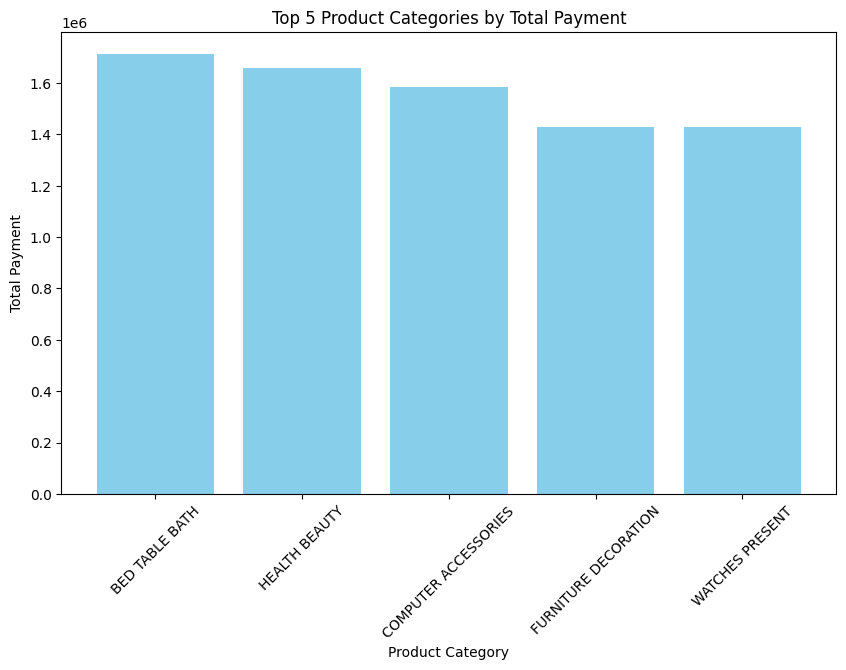

In [13]:
query = """
SELECT 
    UPPER(products.product_category) AS category,
    SUM(ROUND(payments.payment_value)) AS total_payment
FROM products
JOIN order_items 
    ON products.product_id = order_items.product_id
JOIN payments 
    ON payments.order_id = order_items.order_id
GROUP BY category
ORDER BY total_payment DESC
LIMIT 5;  -- top 5 categories
"""
cursor.execute(query)
data = cursor.fetchall()

# create dataframe
df = pd.DataFrame(data, columns=["Category", "Total Payment"])

# plot
plt.figure(figsize=(10,6))
plt.bar(df["Category"], df["Total Payment"], color='skyblue')
plt.title("Top 5 Product Categories by Total Payment")
plt.xlabel("Product Category")
plt.ylabel("Total Payment")
plt.xticks(rotation=45)
plt.show()


# 4. Calculate the percentage of orders that were paid in installments.

In [19]:
query = """
SELECT 
    SUM(CASE WHEN payment_installments > 1 THEN 1 ELSE 0 END) AS installment_count,
    COUNT(*) AS total_count
FROM payments;
"""
cursor.execute(query)
data = cursor.fetchone()
print(data)

(Decimal('49.42'),)


# 5. Count the number of customers from each state. 

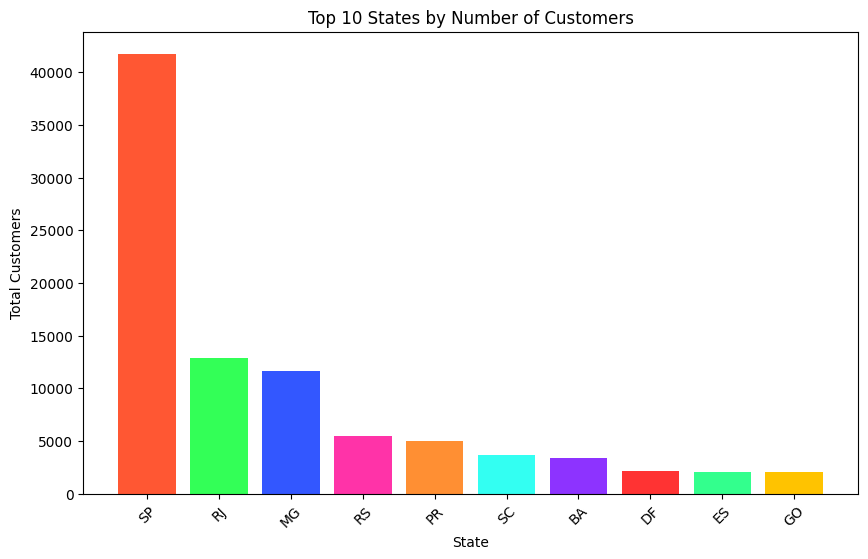

In [23]:
query = """
SELECT customer_state, COUNT(customer_id) AS total_customers
FROM customers
GROUP BY customer_state
ORDER BY total_customers DESC;
"""
cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns=["State", "Total Customers"])
df_top = df.head(10)

colors = ['#FF5733', '#33FF57', '#3357FF', '#FF33A8', '#FF8F33', 
          '#33FFF2', '#8D33FF', '#FF3333', '#33FF8D', '#FFC300']

plt.figure(figsize=(10,6))
plt.bar(df_top["State"], df_top["Total Customers"], color=colors)
plt.title("Top 10 States by Number of Customers")
plt.xlabel("State")
plt.ylabel("Total Customers")
plt.xticks(rotation=45)
plt.show()


# 6. Calculate the number of orders per month in 2018.

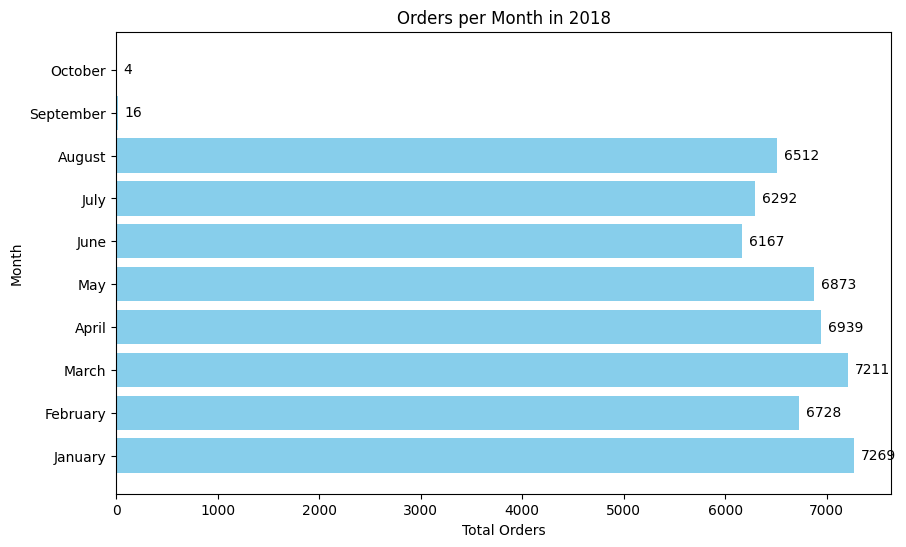

In [32]:
query = """
SELECT 
    MONTHNAME(order_purchase_timestamp) AS month,
    COUNT(order_id) AS total_orders
FROM orders
WHERE YEAR(order_purchase_timestamp) = 2018
GROUP BY MONTH(order_purchase_timestamp), MONTHNAME(order_purchase_timestamp)
ORDER BY MONTH(order_purchase_timestamp);

"""
cursor.execute(query)
data = cursor.fetchall()

df = pd.DataFrame(data, columns=["Month", "Total Orders"])

plt.figure(figsize=(10,6))
bars = plt.barh(df["Month"], df["Total Orders"], color='skyblue')
plt.title("Orders per Month in 2018")
plt.xlabel("Total Orders")
plt.ylabel("Month")
plt.bar_label(bars, fmt='%d', padding=5)
plt.show()

# 7. Find the average number of products per order, grouped by customer city.

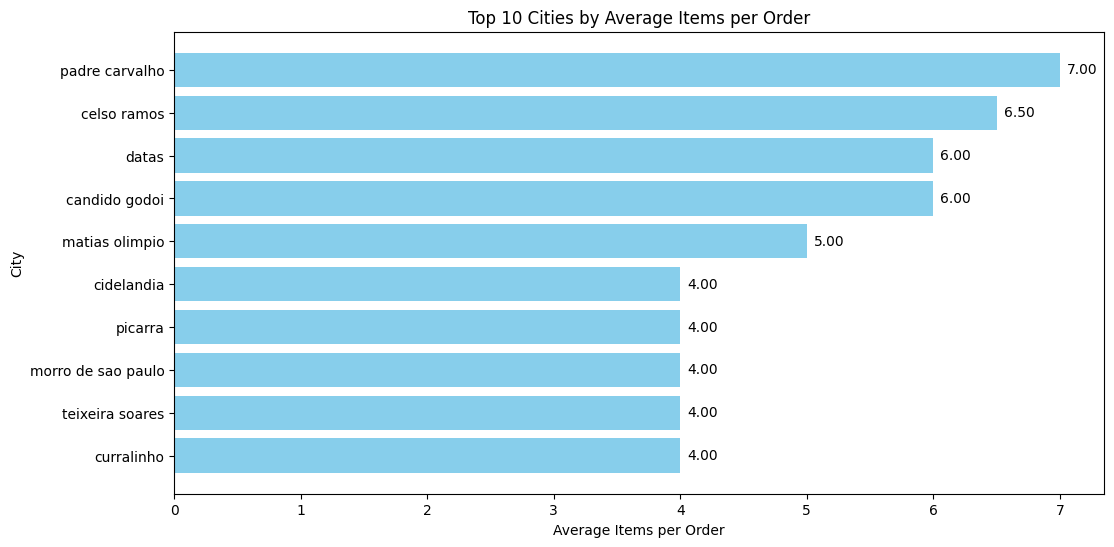

In [36]:
query = """
WITH countperorder AS (
    SELECT 
        orders.customer_id,
        orders.order_id,
        COUNT(order_items.order_id) AS oc
    FROM orders
    JOIN order_items ON orders.order_id = order_items.order_id
    GROUP BY orders.customer_id, orders.order_id
)
SELECT 
    customers.customer_city,
    ROUND(AVG(countperorder.oc), 2) AS avg_orders
FROM customers
JOIN countperorder 
    ON customers.customer_id = countperorder.customer_id
GROUP BY customers.customer_city order by avg_orders desc ;

"""

cursor.execute(query)
city_data = cursor.fetchall()
df = pd.DataFrame(city_data, columns=["City", "Avg Orders"])
df["Avg Orders"] = df["Avg Orders"].astype(float)
df_top = df.head(10)

plt.figure(figsize=(12,6))
bars = plt.barh(df_top["City"], df_top["Avg Orders"], color='skyblue')
plt.title("Top 10 Cities by Average Items per Order")
plt.xlabel("Average Items per Order")
plt.ylabel("City")
plt.gca().invert_yaxis()  # highest avg on top
plt.bar_label(bars, fmt='%.2f', padding=5)
plt.show()

# 8. Calculate the percentage of total revenue contributed by each product category.

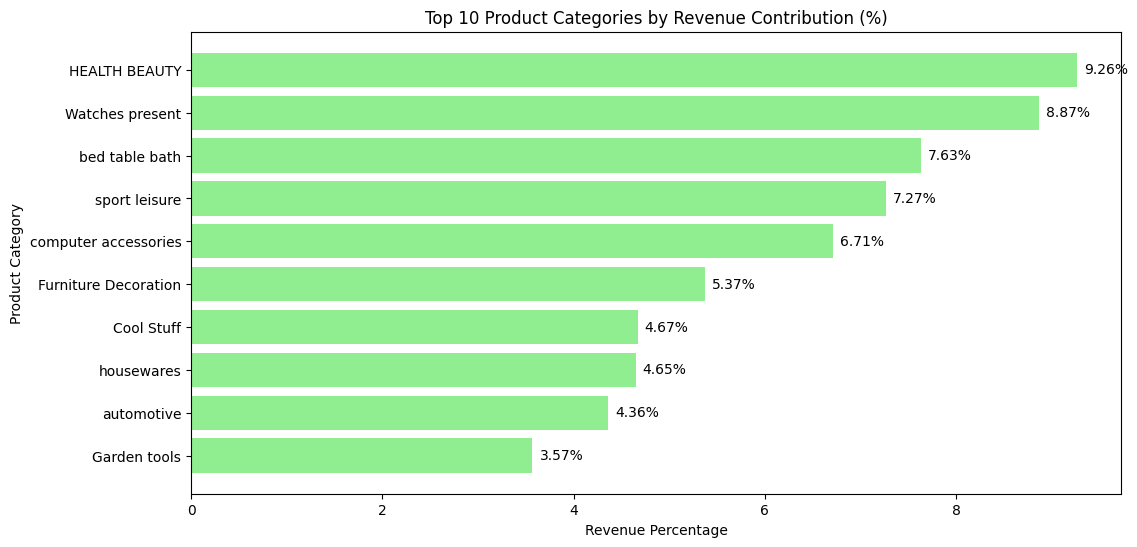

In [4]:
db = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Boom189MBA",
    database="ecommerce"
)
cursor = db.cursor()

query = """
WITH pricebyid AS (
    SELECT 
        order_items.product_id,
        order_items.price
    FROM order_items
)
SELECT 
    products.product_category AS cat,
    ROUND(SUM(pricebyid.price) / (SELECT SUM(price) FROM order_items) * 100, 2) AS revenue_percentage
FROM products
JOIN pricebyid 
    ON products.product_id = pricebyid.product_id
GROUP BY products.product_category
ORDER BY revenue_percentage DESC;
"""

cursor.execute(query)
cat_data = cursor.fetchall()
df = pd.DataFrame(cat_data, columns=["Category", "Revenue %"])
df["Revenue %"] = df["Revenue %"].astype(float)
df_top = df.head(10)

plt.figure(figsize=(12,6))
bars = plt.barh(df_top["Category"], df_top["Revenue %"], color='lightgreen')
plt.title("Top 10 Product Categories by Revenue Contribution (%)")
plt.xlabel("Revenue Percentage")
plt.ylabel("Product Category")
plt.gca().invert_yaxis() 

plt.bar_label(bars, fmt='%.2f%%', padding=5)

plt.show()

# 9. Identify the correlation between product price and the number of times a product has been purchased.

In [6]:
import numpy as np

query = """
SELECT products.product_category, 
       COUNT(order_items.product_id) AS order_count, 
       ROUND(AVG(order_items.price), 2) AS avg_price
FROM products
JOIN order_items 
  ON products.product_id = order_items.product_id
GROUP BY products.product_category;
"""
cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns=["Category", "Order Count", "Average Price"])
order_counts = df["Order Count"].to_numpy()
avg_prices = df["Average Price"].to_numpy()

correlation_matrix = np.corrcoef(order_counts, avg_prices)
correlation = correlation_matrix[0,1]
print("Correlation between order count and average price:", correlation , " this refers to no such effect (neutral)")


Correlation between order count and average price: -0.10631514167157562  this refers to no such effect (neutral)


# 10. Calculate the total revenue generated by each seller, and rank them by revenue.

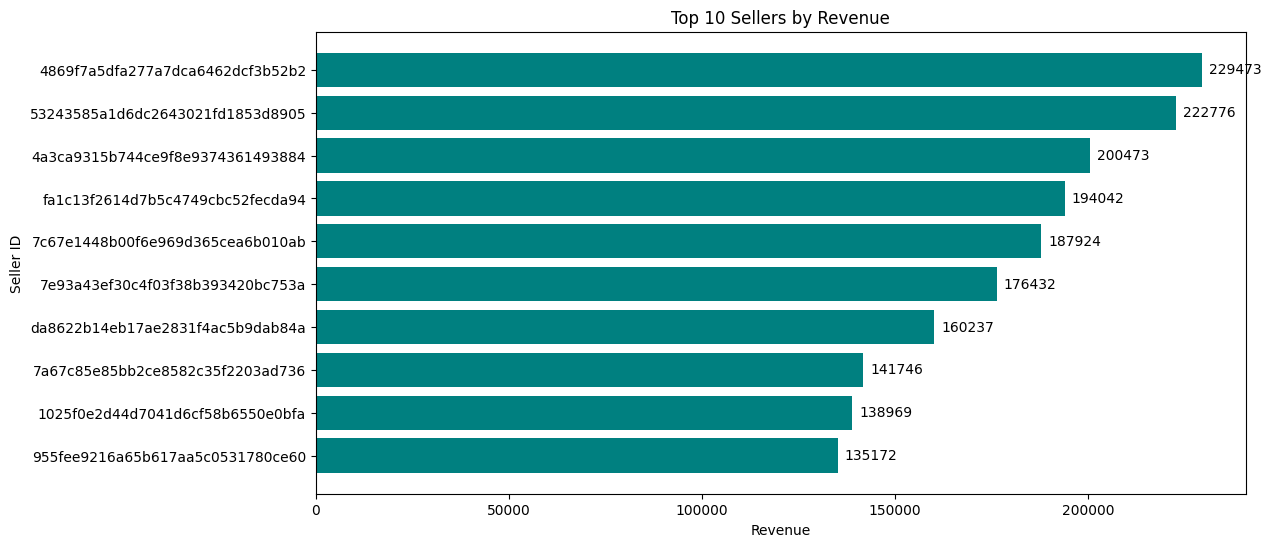

In [7]:
query = """
SELECT 
    sellers.seller_id,
    ROUND(SUM(order_items.price), 0) AS rev
FROM order_items
JOIN sellers 
    ON sellers.seller_id = order_items.seller_id
GROUP BY sellers.seller_id
ORDER BY rev DESC;
"""

cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns=["Seller ID", "Revenue"])
df_top = df.head(10)

plt.figure(figsize=(12,6))
bars = plt.barh(df_top["Seller ID"], df_top["Revenue"], color='teal')
plt.xlabel("Revenue")
plt.ylabel("Seller ID")
plt.title("Top 10 Sellers by Revenue")
plt.gca().invert_yaxis()  # highest revenue on top

# Show revenue values on bars
plt.bar_label(bars, fmt='%d', padding=5)

plt.show()